# MICROBENCH: Benching latency and energy usage in dl operations

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

## BATCH SIZE

In [13]:
CSV_FILE = "./tmp/linear_latency_results_batch_size.csv"
METRIC = "batch_size"
MAX_METRIC_VALUE = 300

df = pd.read_csv(CSV_FILE)
df

,batch_size,Avg Latency (ms)
0,1,0.084410
1,2,0.076278
2,3,0.091475
3,4,0.092006
4,5,0.093056
...,...,...
251,252,0.476893
252,253,0.475795
253,254,0.476902
254,255,0.477136


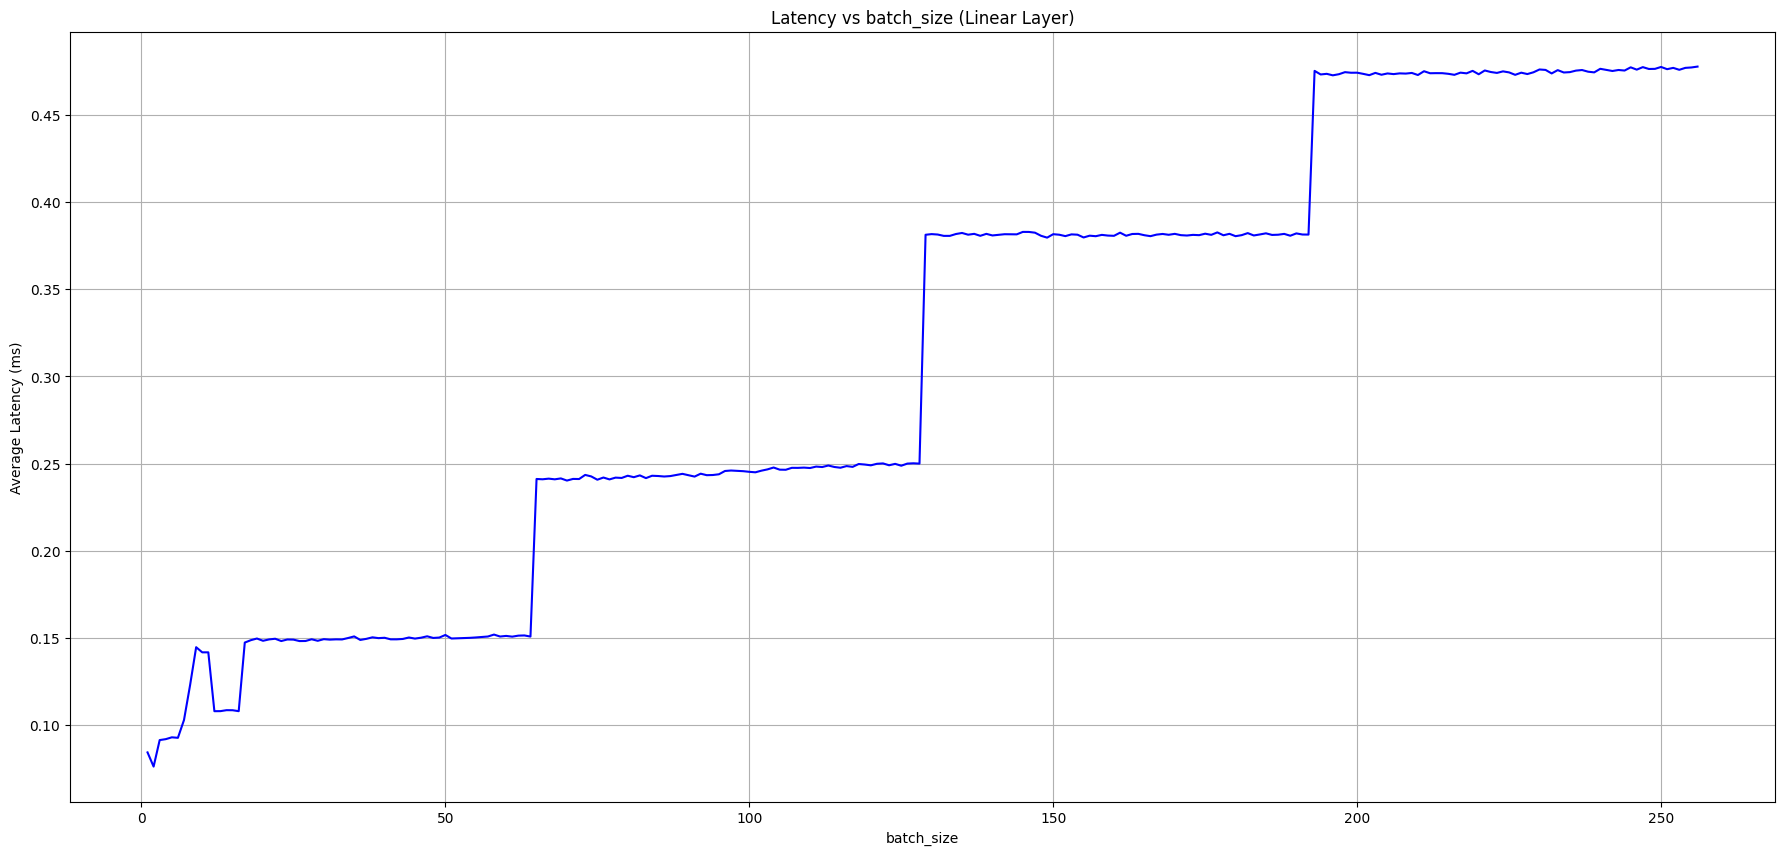

In [15]:
df = df[df[METRIC] < MAX_METRIC_VALUE]
metric = df[METRIC].values
avg_latencies = df["Avg Latency (ms)"].values


plt.figure(figsize=(22, 10))
plt.plot(metric, avg_latencies, linestyle='-', color='b')
plt.xlabel(METRIC)
plt.ylabel("Average Latency (ms)")
plt.title(f"Latency vs {METRIC} (Linear Layer)")
plt.grid(True)
#plt.savefig(f"{NAME_OUTPUT}.png")
plt.show()


## SEQUENCE LENGTH

In [17]:
CSV_FILE = "./tmp/linear_latency_results_seq_length.csv"
METRIC = "seq_len"
MAX_METRIC_VALUE = 1000

df = pd.read_csv(CSV_FILE)
df

,hidden_dim,ffn_dim,seq_len,batch_size,avg_latency_ms
0,4096,11008,1,1,0.071037
1,4096,11008,2,1,0.075699
2,4096,11008,3,1,0.092816
3,4096,11008,4,1,0.091699
4,4096,11008,5,1,0.091709
...,...,...,...,...,...
506,4096,11008,507,1,0.931373
507,4096,11008,508,1,0.930589
508,4096,11008,509,1,0.932566
509,4096,11008,510,1,0.931936


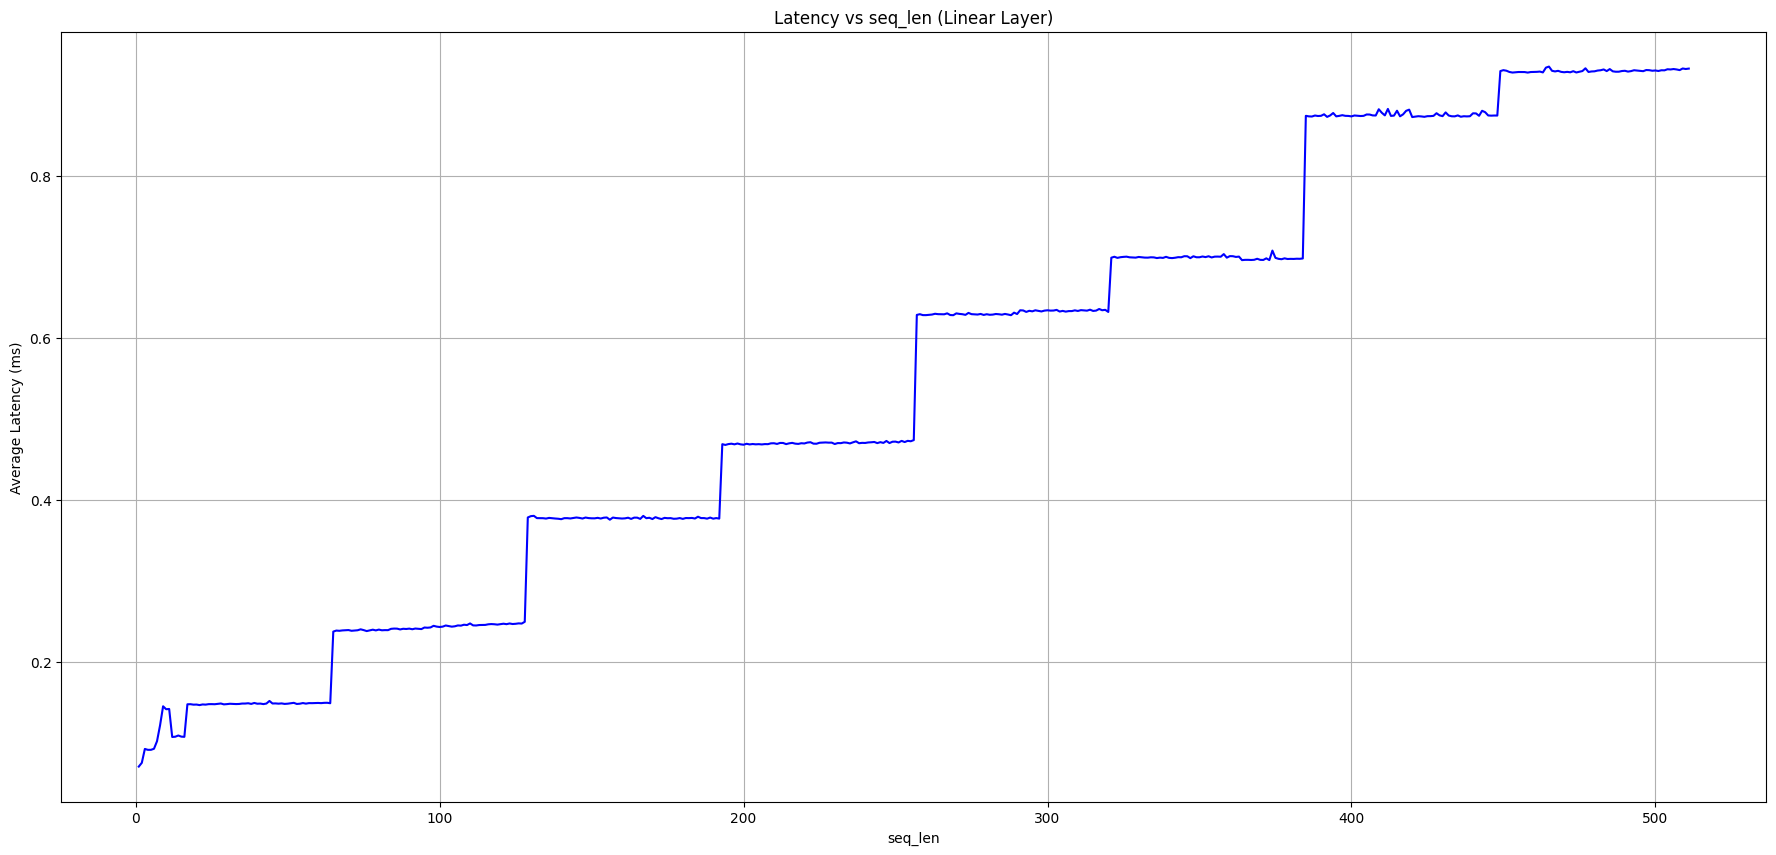

In [18]:
df = df[df[METRIC] < MAX_METRIC_VALUE]
metric = df[METRIC].values
avg_latencies = df["avg_latency_ms"].values


plt.figure(figsize=(22, 10))
plt.plot(metric, avg_latencies, linestyle='-', color='b')
plt.xlabel(METRIC)
plt.ylabel("Average Latency (ms)")
plt.title(f"Latency vs {METRIC} (Linear Layer)")
plt.grid(True)
#plt.savefig(f"{NAME_OUTPUT}.png")
plt.show()


## HIDDEN DIM

In [6]:
CSV_FILE = "./tmp/linear_latency_results_hidden_dims.csv"
METRIC = "hidden_dim"
MAX_METRIC_VALUE = 100_000

df = pd.read_csv(CSV_FILE)
df

,hidden_dim,ffn_dim,seq_len,batch_size,avg_latency_ms
0,1,11008,1,1,0.039891
1,2,11008,1,1,0.032861
2,3,11008,1,1,0.032576
3,4,11008,1,1,0.032797
4,5,11008,1,1,0.035216
...,...,...,...,...,...
16378,16379,11008,1,1,0.241942
16379,16380,11008,1,1,0.242275
16380,16381,11008,1,1,0.242102
16381,16382,11008,1,1,0.242806


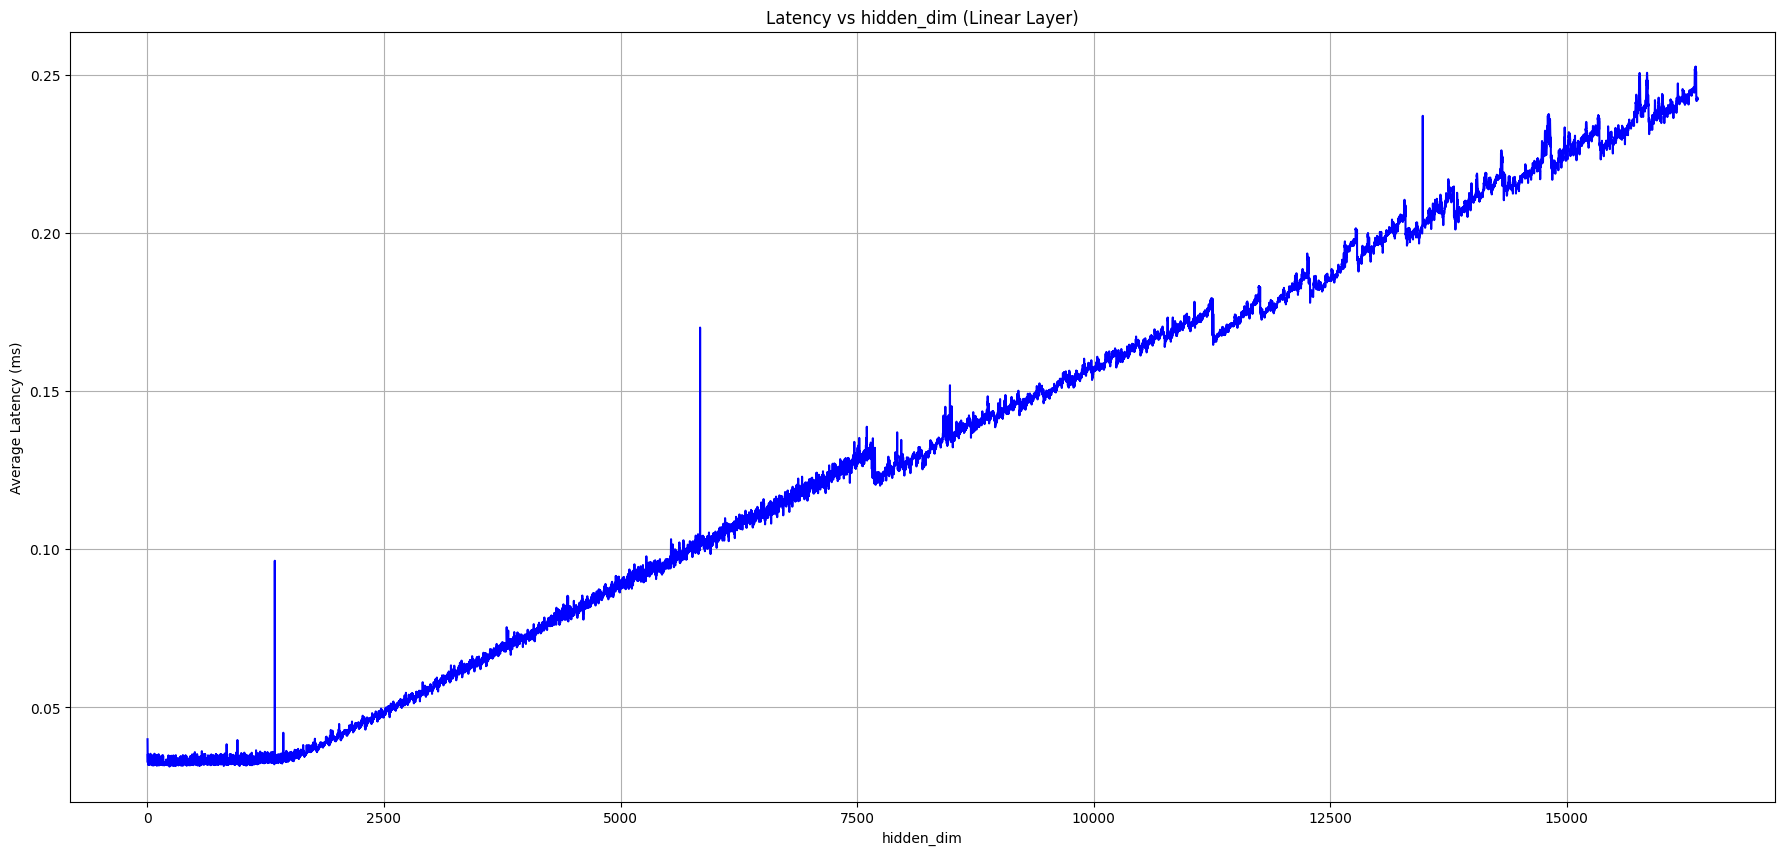

In [7]:
MAX_METRIC_VALUE = 500000

metric = df[METRIC].values
avg_latencies = df["avg_latency_ms"].values


plt.figure(figsize=(22, 10))
plt.plot(metric, avg_latencies, linestyle='-', color='b')
plt.xlabel(METRIC)
plt.ylabel("Average Latency (ms)")
plt.title(f"Latency vs {METRIC} (Linear Layer)")
plt.grid(True)
#plt.savefig(f"{NAME_OUTPUT}.png")
plt.show()


## FFN DIM

In [27]:
CSV_FILE = "./tmp/linear_latency_results_ffn_dims.csv"
METRIC = "ffn_dim"
MAX_METRIC_VALUE = 100_000

df = pd.read_csv(CSV_FILE)
df

,hidden_dim,ffn_dim,seq_len,batch_size,avg_latency_ms
0,4096,1,1,1,0.036688
1,4096,2,1,1,0.034627
2,4096,3,1,1,0.034336
3,4096,4,1,1,0.033814
4,4096,5,1,1,0.034336
...,...,...,...,...,...
65530,4096,65531,1,1,0.346966
65531,4096,65532,1,1,0.346064
65532,4096,65533,1,1,0.346704
65533,4096,65534,1,1,0.346022


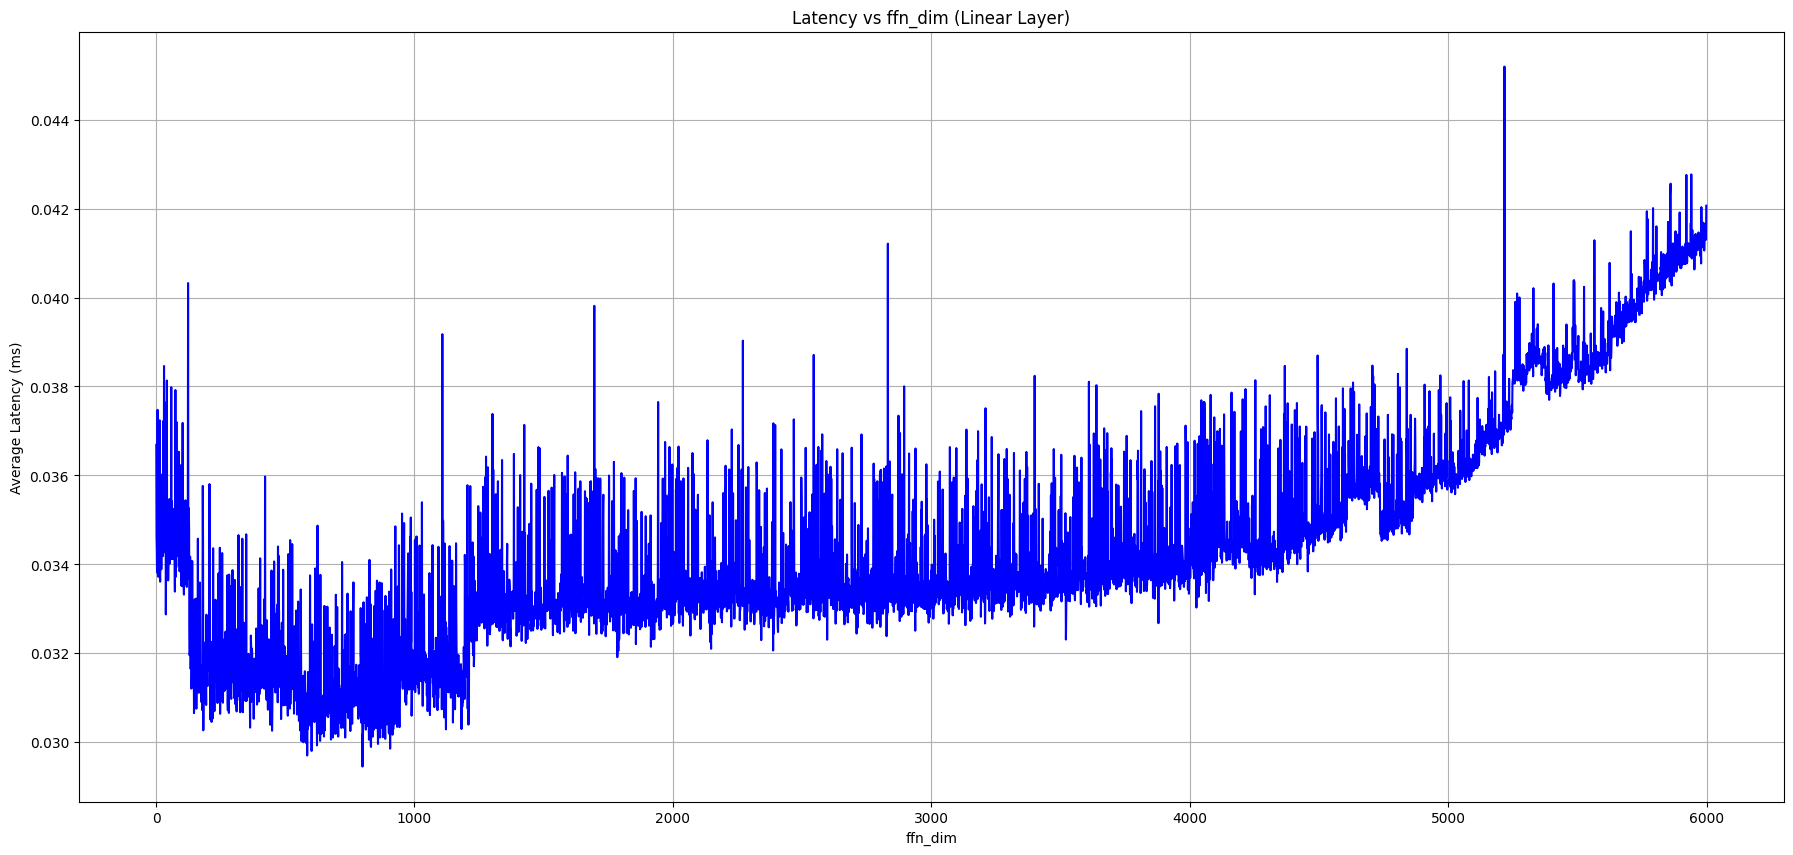

In [28]:
MAX_METRIC_VALUE = 6000
df = df[df[METRIC] < MAX_METRIC_VALUE]
metric = df[METRIC].values
avg_latencies = df["avg_latency_ms"].values


plt.figure(figsize=(22, 10))
plt.plot(metric, avg_latencies, linestyle='-', color='b')
plt.xlabel(METRIC)
plt.ylabel("Average Latency (ms)")
plt.title(f"Latency vs {METRIC} (Linear Layer)")
plt.grid(True)
#plt.savefig(f"{NAME_OUTPUT}.png")
plt.show()


## TODO
- Varing metrics
- See if varitaion of kernel at each jump (plot max used kernel per metric ?)
- mesure energy usage nvml
- Try attention layer


In [1]:
hidden_dim = 4096  # Input dimension
ffn_dim = 11008  # Output dimension
batch_size = 1  # Batch size
seq_len = 1  # Sequence length
dtype_size = 4  # Size of float32 in bytes

total_memory = ((hidden_dim * ffn_dim) + (batch_size * seq_len * hidden_dim) + (batch_size * seq_len * ffn_dim)) * dtype_size
print(f"Total memory required for the model: {total_memory/(1024*1024):.2f} MB")

# L2 cache size 50 MB
l2_cache_size = 50 * 1024 * 1024  # MB to bytes

max_hidden_dim = ((l2_cache_size / dtype_size) - (batch_size * seq_len * ffn_dim)) / (ffn_dim + batch_size * seq_len)
print(f"Maximum hidden dimension that fits in L2 cache: {max_hidden_dim:.2f}")

max_ffn_dim = ((l2_cache_size / dtype_size) - (batch_size * seq_len * hidden_dim)) / (hidden_dim + batch_size * seq_len)
print(f"Maximum FFN dimension that fits in L2 cache: {max_ffn_dim:.2f}")

max_batch_size = (l2_cache_size / dtype_size - (hidden_dim * ffn_dim)) / (seq_len * (hidden_dim + ffn_dim))
print(f"Maximum batch size that fits in L2 cache: {max_batch_size:.2f}")

max_seq_len = (l2_cache_size / dtype_size - (hidden_dim * ffn_dim)) / (batch_size * (hidden_dim + ffn_dim))
print(f"Maximum sequence length that fits in L2 cache: {max_seq_len:.2f}")



Total memory required for the model: 172.06 MB
Maximum hidden dimension that fits in L2 cache: 1189.59
Maximum FFN dimension that fits in L2 cache: 3198.22
Maximum batch size that fits in L2 cache: -2117.42
Maximum sequence length that fits in L2 cache: -2117.42


In [2]:
max_hidden_dim_found = 1500  # Input dimension
max_ffn_dim_found = 4100  # Output dimension
batch_size = 1  # Batch size
seq_len = 1  # Sequence length
dtype_size = 4  # Size of float32 in bytes

total_memory_hidden_dim = ((max_hidden_dim_found * ffn_dim) + (batch_size * seq_len * max_hidden_dim_found) + (batch_size * seq_len * ffn_dim)) * dtype_size
total_memory_ffn_dim = ((hidden_dim * max_ffn_dim_found) + (batch_size * seq_len * hidden_dim) + (batch_size * seq_len * max_ffn_dim_found)) * dtype_size
print(f"Max cached memory according to hidden dim : {total_memory_hidden_dim/(1024*1024):.2f} MB")
print(f"Max cached memory according to ffn dim : {total_memory_ffn_dim/(1024*1024):.2f} MB")




Max cached memory according to hidden dim : 63.04 MB
Max cached memory according to ffn dim : 64.09 MB


In [3]:
hidden_dim = 4096  # Input dimension
ffn_dim = 11008  # Output dimension
batch_size = 1  # Batch size
seq_len = 1  # Sequence length
dtype_size = 4  # Size of float32 in bytes

total_memory_cached = (hidden_dim * ffn_dim) * dtype_size
print(f"Total memory required for the model: {total_memory/(1024*1024):.2f} MB")

# L2 cache size 50 MB
l2_cache_size = 50 * 1024 * 1024  # MB to bytes

max_hidden_dim = l2_cache_size / (ffn_dim * dtype_size)
print(f"Maximum hidden dimension that fits in L2 cache: {max_hidden_dim:.2f}")

max_ffn_dim = l2_cache_size / (hidden_dim * dtype_size)
print(f"Maximum FFN dimension that fits in L2 cache: {max_ffn_dim:.2f}")




Total memory required for the model: 172.06 MB
Maximum hidden dimension that fits in L2 cache: 1190.70
Maximum FFN dimension that fits in L2 cache: 3200.00


In [5]:
50 *1024*1024 / (4096 * 4)  # 45 MB L2 cache size, hidden_dim = 4096, dtype_size = 4 bytes

3200.0

In [7]:
45 *1024*1024 / (11008 * 4)

1071.6279069767443

## Power trace

In [ ]:
import pandas as pd
power_df = pd.read_csv("./tmp/llama3_power_trace_2025-07-03-15-16-22.csv")
power_df

,time_ns,power_w,time_ms
0,290,119.327,0.000290
1,1964332,119.327,1.964332
2,2197397,119.327,2.197397
3,2360880,119.327,2.360880
4,2524174,119.327,2.524174
...,...,...,...
5195,840488058,291.391,840.488058
5196,840655412,291.391,840.655412
5197,840816695,291.391,840.816695
5198,840976589,291.391,840.976589


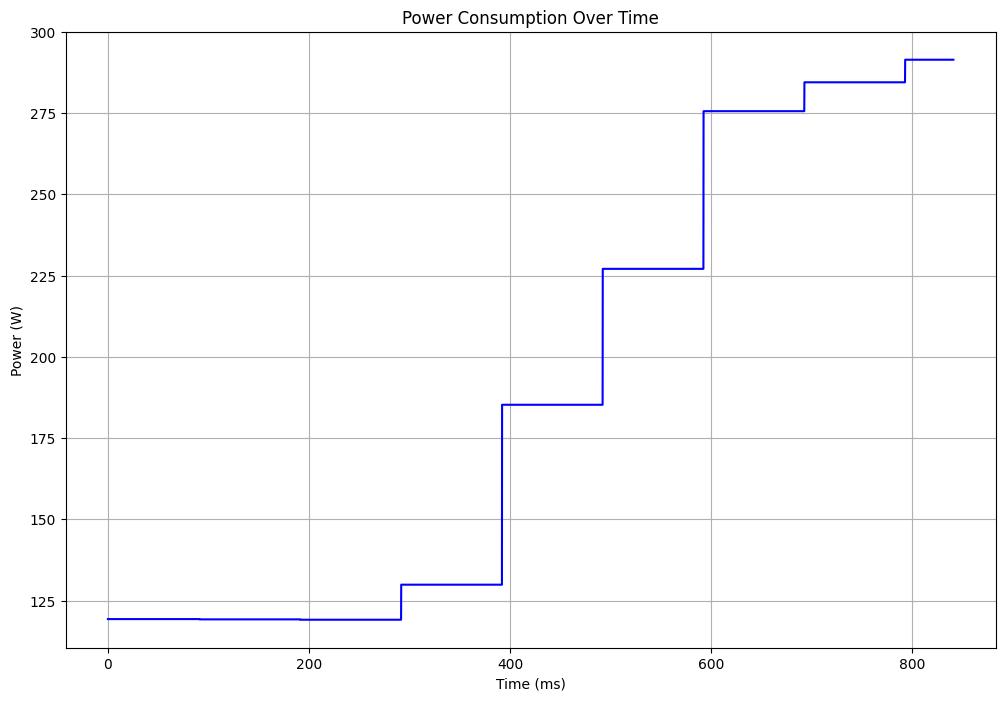

In [4]:
import matplotlib.pyplot as plt
import numpy as np
plt.figure(figsize=(12, 8))
plt.plot(power_df["time_ms"], power_df["power_w"], linestyle='-', color='b')
plt.xlabel("Time (ms)")
plt.ylabel("Power (W)")
plt.title("Power Consumption Over Time")
plt.grid(True)
#plt.savefig(f"{NAME_OUTPUT}.png")
plt.show()

### Power Prefill phase

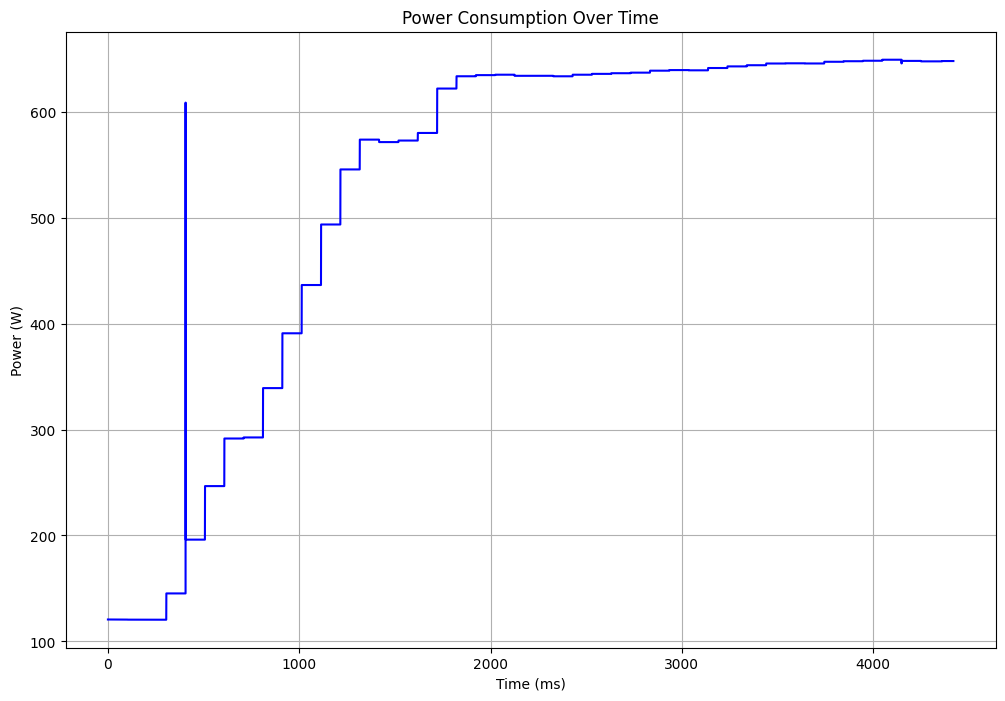

In [5]:
import pandas as pd
power_df = pd.read_csv("./tmp/llama3_power_trace_2025-07-03-15-47-41.csv")
power_df
import matplotlib.pyplot as plt
import numpy as np
plt.figure(figsize=(12, 8))
plt.plot(power_df["time_ms"], power_df["power_w"], linestyle='-', color='b')
plt.xlabel("Time (ms)")
plt.ylabel("Power (W)")
plt.title("Power Consumption Over Time")
plt.grid(True)
#plt.savefig(f"{NAME_OUTPUT}.png")
plt.show()

### Power Decode phase

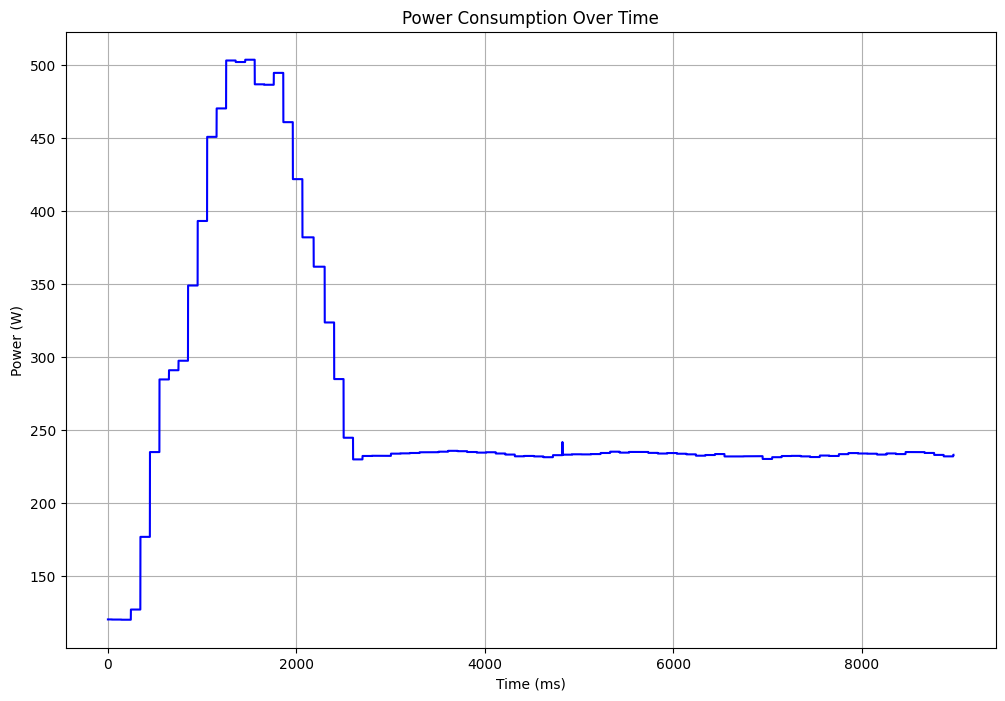

In [6]:

import pandas as pd
power_df = pd.read_csv("./tmp/llama3_power_trace_2025-07-03-15-50-37.csv")
power_df
import matplotlib.pyplot as plt
import numpy as np
plt.figure(figsize=(12, 8))
plt.plot(power_df["time_ms"], power_df["power_w"], linestyle='-', color='b')
plt.xlabel("Time (ms)")
plt.ylabel("Power (W)")
plt.title("Power Consumption Over Time")
plt.grid(True)
#plt.savefig(f"{NAME_OUTPUT}.png")
plt.show()

## Comparaison torch.compile energy

### Decode

In [3]:
import pandas as pd
csv_decode_compile = pd.read_csv("./tmp/energyllama8Bcompile_generate_results_bs1_input_length128_runs5_2025-07-10-15-01-17.csv")
csv_decode_nocompile = pd.read_csv("./tmp/energyllama8B_generate_results_bs1_input_length128_runs5_2025-07-10-15-04-11.csv")
csv_decode_nocompile

,duration_generate,energy_generate_cpu,energy_generate_gpu,energy_generate_ram
0,12340.172656,0.000346,0.000899,0.000069


In [4]:
csv_decode_compile

,duration_generate,energy_generate_cpu,energy_generate_gpu,energy_generate_ram
0,17931.073437,0.000462,0.00131,0.0001


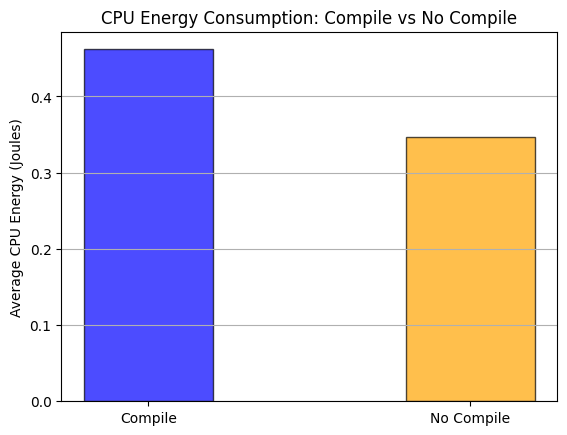

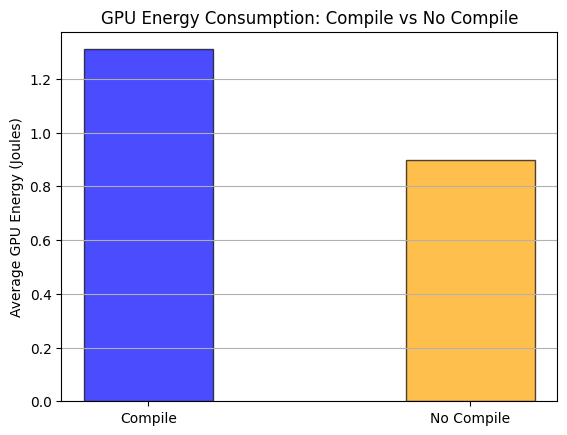

In [9]:
import matplotlib.pyplot as plt
plt.bar(['Compile', 'No Compile'], 
        [csv_decode_compile['energy_generate_cpu'].mean()*1000, csv_decode_nocompile['energy_generate_cpu'].mean()*1000], 
        color=['blue', 'orange'], edgecolor='black', alpha=0.7, width=0.4)
plt.ylabel('Average CPU Energy (Joules)')
plt.title('CPU Energy Consumption: Compile vs No Compile')
plt.grid(axis='y')
plt.show()

import matplotlib.pyplot as plt
plt.bar(['Compile', 'No Compile'], 
        [csv_decode_compile['energy_generate_gpu'].mean()*1000, csv_decode_nocompile['energy_generate_gpu'].mean()*1000], 
        color=['blue', 'orange'], edgecolor='black', alpha=0.7, width=0.4)
plt.ylabel('Average GPU Energy (Joules)')
plt.title('GPU Energy Consumption: Compile vs No Compile')
plt.grid(axis='y')
plt.show()

In [13]:
df_compile_energy = pd.read_csv("./tmp/energyllama8Bcommpile_decodeprefillgenerate_results_bs1_input_length128_runs20_2025-07-10-15-45-38.csv")
df_nocompile_energy = pd.read_csv("./tmp/energyllama8B_decodeprefillgenerate_results_bs1_input_length128_runs20_2025-07-10-15-59-50.csv")
df_nocompile_energy

,model,batch_size,input_length,generate_length,runs,duration_prefill,energy_prefill_cpu,energy_prefill_gpu,energy_prefill_ram,duration_generate,energy_generate_cpu,energy_generate_gpu,energy_generate_ram,duration_decode,energy_decode_cpu,energy_decode_gpu,energy_decode_ram
0,meta-llama/Llama-3.1-8B-Instruct,1,128,500,20,49.527417,0.000002,0.000009,4.163730e-07,9615.357813,0.000238,0.000839,0.000054,9565.830396,0.000237,0.00083,0.000053


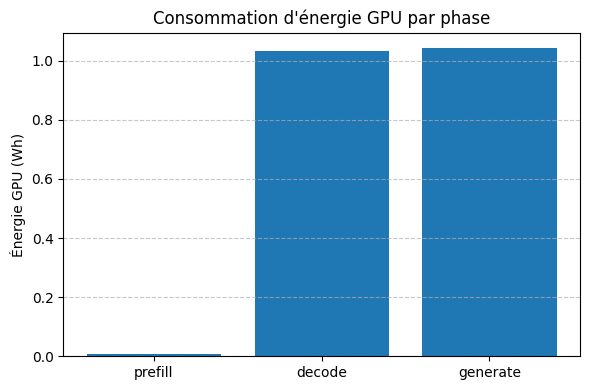

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

# Lecture du fichier
df = pd.read_csv("./tmp/energyllama8Bcommpile_decodeprefillgenerate_results_bs1_input_length128_runs20_2025-07-10-15-45-38.csv")

# Conversion des énergies GPU de kWh vers Wh
energy_wh = {
    "prefill": df["energy_prefill_gpu"].iloc[0] * 1000,
    "decode": df["energy_decode_gpu"].iloc[0] * 1000,
    "generate": df["energy_generate_gpu"].iloc[0] * 1000,
}

# Tracé du bar plot
plt.figure(figsize=(6, 4))
plt.bar(energy_wh.keys(), energy_wh.values())
plt.ylabel("Énergie GPU (Wh)")
plt.title("Consommation d'énergie GPU par phase")
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


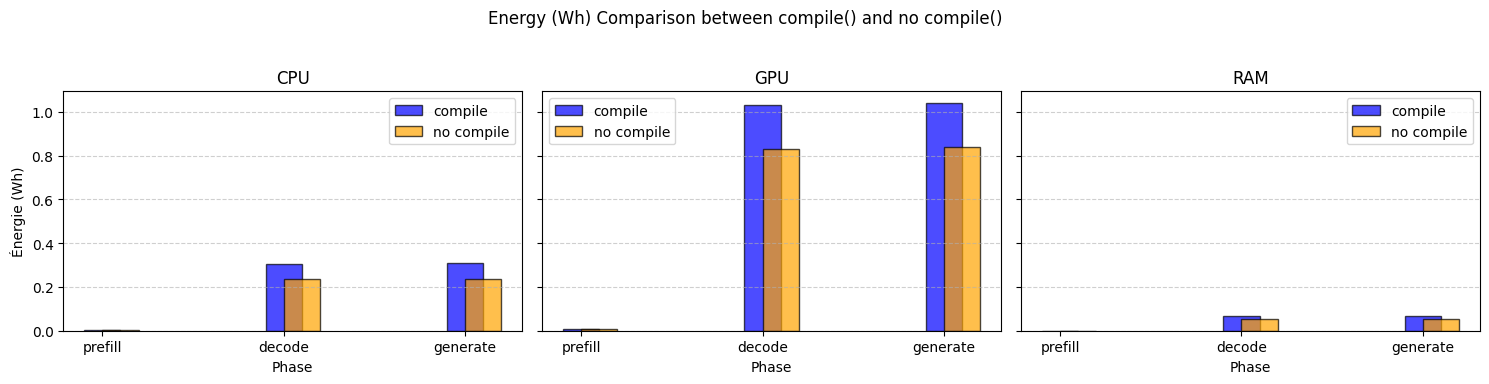

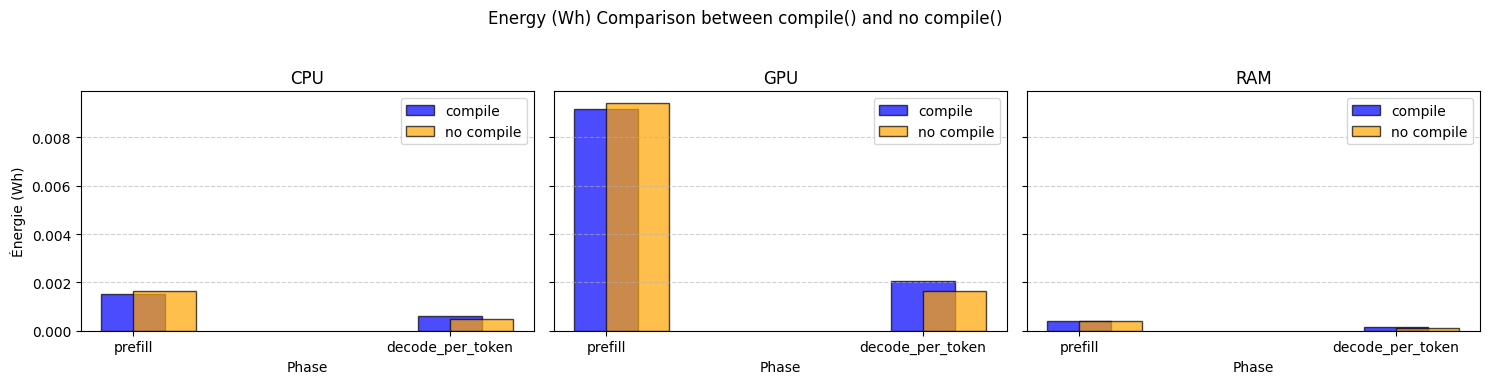

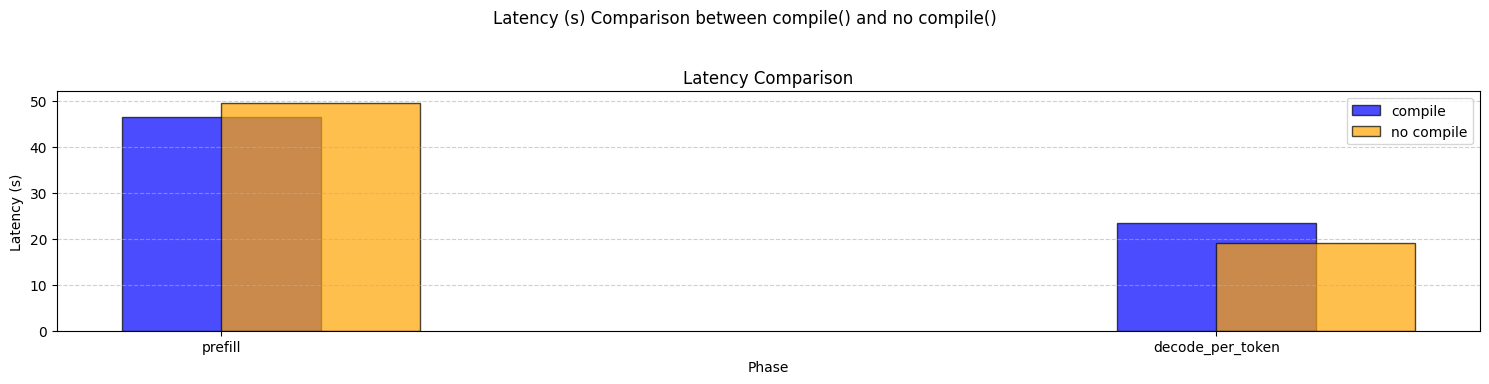

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Chargement des fichiers
df_compile = pd.read_csv("./tmp/energyllama8Bcommpile_decodeprefillgenerate_results_bs1_input_length128_runs20_2025-07-10-15-45-38.csv")
df_nocompile = pd.read_csv("./tmp/energyllama8B_decodeprefillgenerate_results_bs1_input_length128_runs20_2025-07-10-15-59-50.csv")

df_compile['energy_decode_per_token_cpu'] = df_compile['energy_decode_cpu'] / df_compile['generate_length']
df_nocompile['energy_decode_per_token_cpu'] = df_nocompile['energy_decode_cpu'] / df_nocompile['generate_length']
df_compile['energy_decode_per_token_gpu'] = df_compile['energy_decode_gpu'] / df_compile['generate_length']
df_nocompile['energy_decode_per_token_gpu'] = df_nocompile['energy_decode_gpu'] / df_nocompile['generate_length']
df_compile['energy_decode_per_token_ram'] = df_compile['energy_decode_ram'] / df_compile['generate_length']
df_nocompile['energy_decode_per_token_ram'] = df_nocompile['energy_decode_ram'] / df_nocompile['generate_length']
df_compile['duration_decode_per_token'] = df_compile['duration_decode'] / df_compile['generate_length']
df_nocompile['duration_decode_per_token'] = df_nocompile['duration_decode'] / df_nocompile['generate_length']


# Initialisation
phases = ["prefill", "decode", "generate"]
devices = ["cpu", "gpu", "ram"]

# Création des subplots
fig, axs = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
fig.suptitle("Energy (Wh) Comparison between compile() and no compile()")

for idx, device in enumerate(devices):
    energies_compile = [df_compile[f"energy_{phase}_{device}"].iloc[0] * 1000 for phase in phases]
    energies_nocompile = [df_nocompile[f"energy_{phase}_{device}"].iloc[0] * 1000 for phase in phases]
    
    axs[idx].bar(phases, energies_compile, width=0.2, label="compile", align='center', color='blue', alpha=0.7, edgecolor='black')
    axs[idx].bar(phases, energies_nocompile, width=0.2, label="no compile", align='edge', color='orange', alpha=0.7, edgecolor='black')
    axs[idx].set_title(device.upper())
    axs[idx].set_xlabel("Phase")
    if idx == 0:
        axs[idx].set_ylabel("Énergie (Wh)")
    axs[idx].grid(True, axis='y', linestyle='--', alpha=0.6)
    axs[idx].legend()

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


# Initialisation
phases = ["prefill", "decode_per_token"]
devices = ["cpu", "gpu", "ram"]

# Création des subplots
fig, axs = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
fig.suptitle("Energy (Wh) Comparison between compile() and no compile()")

for idx, device in enumerate(devices):
    energies_compile = [df_compile[f"energy_{phase}_{device}"].iloc[0] * 1000 for phase in phases]
    energies_nocompile = [df_nocompile[f"energy_{phase}_{device}"].iloc[0] * 1000 for phase in phases]
    
    axs[idx].bar(phases, energies_compile, width=0.2, label="compile", align='center', color='blue', alpha=0.7, edgecolor='black')
    axs[idx].bar(phases, energies_nocompile, width=0.2, label="no compile", align='edge', color='orange', alpha=0.7, edgecolor='black')
    axs[idx].set_title(device.upper())
    axs[idx].set_xlabel("Phase")
    if idx == 0:
        axs[idx].set_ylabel("Énergie (Wh)")
    axs[idx].grid(True, axis='y', linestyle='--', alpha=0.6)
    axs[idx].legend()

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

phases = ["prefill", "decode_per_token"]

fig, axs = plt.subplots(1, 1, figsize=(15, 4), sharey=True)
fig.suptitle("Latency (s) Comparison between compile() and no compile()")

latency_compile = [df_compile[f"duration_{phase}"].iloc[0] for phase in phases]
latency_nocompile = [df_nocompile[f"duration_{phase}"].iloc[0] for phase in phases]

axs.bar(phases, latency_compile, width=0.2, label="compile", align='center', color='blue', alpha=0.7, edgecolor='black')
axs.bar(phases, latency_nocompile, width=0.2, label="no compile", align='edge', color='orange', alpha=0.7, edgecolor='black')
axs.set_title("Latency Comparison")
axs.set_xlabel("Phase")
axs.set_ylabel("Latency (s)")
axs.grid(True, axis='y', linestyle='--', alpha=0.6)
axs.legend()
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


In [26]:
df_nocompile = pd.read_csv("./tmp/energyllama8B_decodeprefillgenerate_results_bs1_input_length128_runs5_2025-07-10-16-23-12.csv")
df_nocompile['duration_decode_per_token'] = df_nocompile['duration_decode'] / (df_nocompile['generate_length']-1)
df_nocompile['energy_decode_per_token_cpu'] = df_nocompile['energy_decode_cpu'] / (df_nocompile['generate_length'] - 1)
df_nocompile['energy_decode_per_token_gpu'] = df_nocompile['energy_decode_gpu'] / (df_nocompile['generate_length'] - 1)
df_nocompile['energy_decode_per_token_ram'] = df_nocompile['energy_decode_ram'] / (df_nocompile['generate_length'] - 1)
df_nocompile

,model,batch_size,input_length,generate_length,runs,duration_prefill,energy_prefill_cpu,energy_prefill_gpu,energy_prefill_ram,duration_generate,...,energy_generate_gpu,energy_generate_ram,duration_decode,energy_decode_cpu,energy_decode_gpu,energy_decode_ram,duration_decode_per_token,energy_decode_per_token_cpu,energy_decode_per_token_gpu,energy_decode_per_token_ram
0,meta-llama/Llama-3.1-8B-Instruct,1,128,10,5,51.57074,0.000004,0.000012,8.507634e-07,408.909644,...,0.000037,0.000003,357.338904,0.00001,0.000025,0.000002,39.704323,0.000001,0.000003,2.205436e-07


In [27]:
df_compile = pd.read_csv("./tmp/energyllama8Bcompile_decodeprefillgenerate_results_bs1_input_length128_runs5_2025-07-10-16-27-55.csv")
df_compile['duration_decode_per_token'] = df_compile['duration_decode'] / (df_compile['generate_length']-1)
df_compile['energy_decode_per_token_cpu'] = df_compile['energy_decode_cpu'] / (df_compile['generate_length'] - 1)
df_compile['energy_decode_per_token_gpu'] = df_compile['energy_decode_gpu'] / (df_compile['generate_length'] - 1)
df_compile['energy_decode_per_token_ram'] = df_compile['energy_decode_ram'] / (df_compile['generate_length'] - 1)

df_compile

,model,batch_size,input_length,generate_length,runs,duration_prefill,energy_prefill_cpu,energy_prefill_gpu,energy_prefill_ram,duration_generate,...,energy_generate_gpu,energy_generate_ram,duration_decode,energy_decode_cpu,energy_decode_gpu,energy_decode_ram,duration_decode_per_token,energy_decode_per_token_cpu,energy_decode_per_token_gpu,energy_decode_per_token_ram
0,meta-llama/Llama-3.1-8B-Instruct,1,128,10,5,47.161734,0.000004,0.000013,8.281048e-07,201.619543,...,0.000028,0.000002,154.457809,0.000004,0.000015,8.569438e-07,17.161979,4.339342e-07,0.000002,9.521598e-08


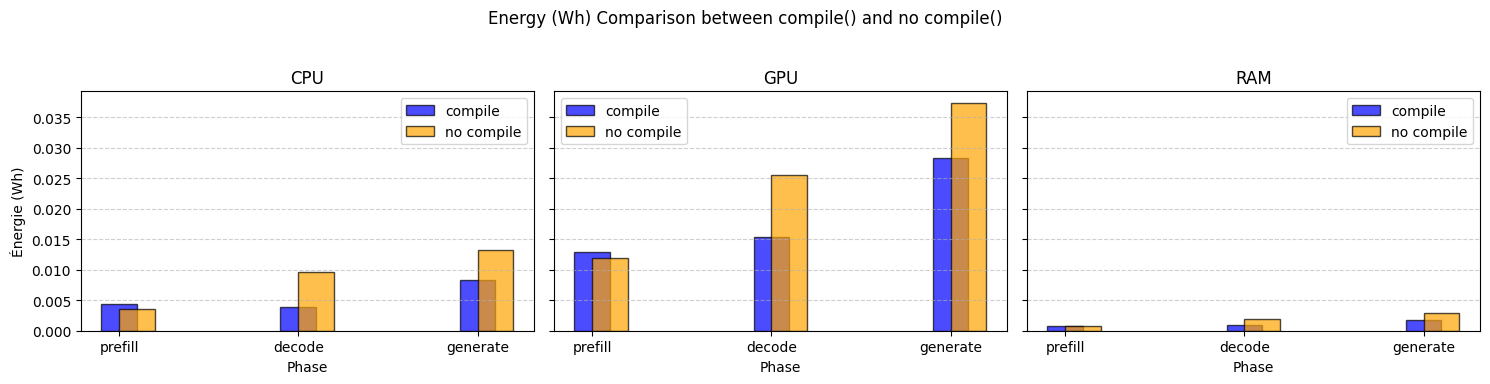

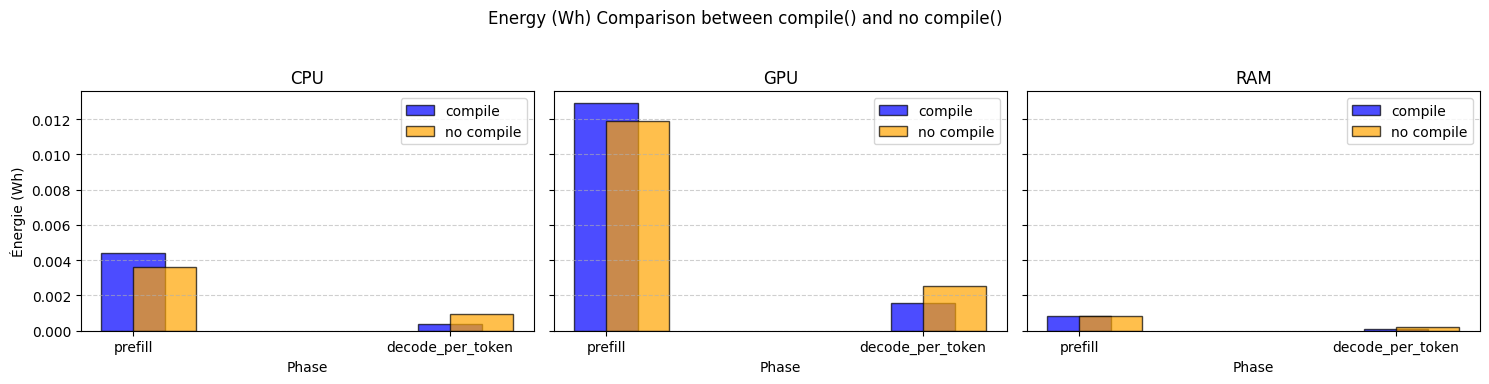

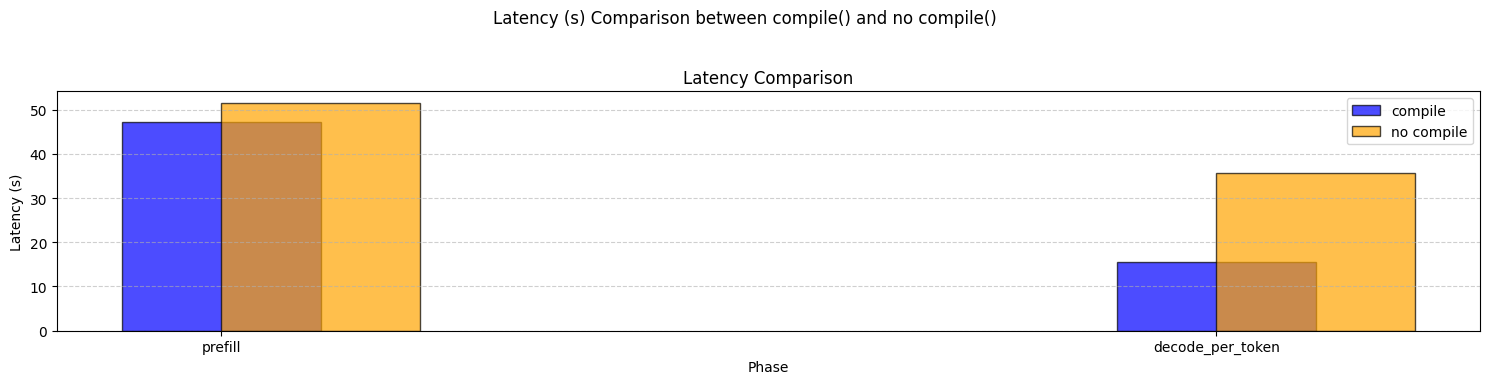

In [28]:
import pandas as pd
import matplotlib.pyplot as plt

df_compile['energy_decode_per_token_cpu'] = df_compile['energy_decode_cpu'] / df_compile['generate_length']
df_nocompile['energy_decode_per_token_cpu'] = df_nocompile['energy_decode_cpu'] / df_nocompile['generate_length']
df_compile['energy_decode_per_token_gpu'] = df_compile['energy_decode_gpu'] / df_compile['generate_length']
df_nocompile['energy_decode_per_token_gpu'] = df_nocompile['energy_decode_gpu'] / df_nocompile['generate_length']
df_compile['energy_decode_per_token_ram'] = df_compile['energy_decode_ram'] / df_compile['generate_length']
df_nocompile['energy_decode_per_token_ram'] = df_nocompile['energy_decode_ram'] / df_nocompile['generate_length']
df_compile['duration_decode_per_token'] = df_compile['duration_decode'] / df_compile['generate_length']
df_nocompile['duration_decode_per_token'] = df_nocompile['duration_decode'] / df_nocompile['generate_length']


# Initialisation
phases = ["prefill", "decode", "generate"]
devices = ["cpu", "gpu", "ram"]

# Création des subplots
fig, axs = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
fig.suptitle("Energy (Wh) Comparison between compile() and no compile()")

for idx, device in enumerate(devices):
    energies_compile = [df_compile[f"energy_{phase}_{device}"].iloc[0] * 1000 for phase in phases]
    energies_nocompile = [df_nocompile[f"energy_{phase}_{device}"].iloc[0] * 1000 for phase in phases]
    
    axs[idx].bar(phases, energies_compile, width=0.2, label="compile", align='center', color='blue', alpha=0.7, edgecolor='black')
    axs[idx].bar(phases, energies_nocompile, width=0.2, label="no compile", align='edge', color='orange', alpha=0.7, edgecolor='black')
    axs[idx].set_title(device.upper())
    axs[idx].set_xlabel("Phase")
    if idx == 0:
        axs[idx].set_ylabel("Énergie (Wh)")
    axs[idx].grid(True, axis='y', linestyle='--', alpha=0.6)
    axs[idx].legend()

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


# Initialisation
phases = ["prefill", "decode_per_token"]
devices = ["cpu", "gpu", "ram"]

# Création des subplots
fig, axs = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
fig.suptitle("Energy (Wh) Comparison between compile() and no compile()")

for idx, device in enumerate(devices):
    energies_compile = [df_compile[f"energy_{phase}_{device}"].iloc[0] * 1000 for phase in phases]
    energies_nocompile = [df_nocompile[f"energy_{phase}_{device}"].iloc[0] * 1000 for phase in phases]
    
    axs[idx].bar(phases, energies_compile, width=0.2, label="compile", align='center', color='blue', alpha=0.7, edgecolor='black')
    axs[idx].bar(phases, energies_nocompile, width=0.2, label="no compile", align='edge', color='orange', alpha=0.7, edgecolor='black')
    axs[idx].set_title(device.upper())
    axs[idx].set_xlabel("Phase")
    if idx == 0:
        axs[idx].set_ylabel("Énergie (Wh)")
    axs[idx].grid(True, axis='y', linestyle='--', alpha=0.6)
    axs[idx].legend()

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

phases = ["prefill", "decode_per_token"]

fig, axs = plt.subplots(1, 1, figsize=(15, 4), sharey=True)
fig.suptitle("Latency (s) Comparison between compile() and no compile()")

latency_compile = [df_compile[f"duration_{phase}"].iloc[0] for phase in phases]
latency_nocompile = [df_nocompile[f"duration_{phase}"].iloc[0] for phase in phases]

axs.bar(phases, latency_compile, width=0.2, label="compile", align='center', color='blue', alpha=0.7, edgecolor='black')
axs.bar(phases, latency_nocompile, width=0.2, label="no compile", align='edge', color='orange', alpha=0.7, edgecolor='black')
axs.set_title("Latency Comparison")
axs.set_xlabel("Phase")
axs.set_ylabel("Latency (s)")
axs.grid(True, axis='y', linestyle='--', alpha=0.6)
axs.legend()
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


In [30]:
df_nocompile = pd.read_csv("./tmp/energyllama8B_decodeprefillgenerate_results_bs1_input_length128_runs50_2025-07-10-16-37-59.csv")
df_nocompile['duration_decode_per_token'] = df_nocompile['duration_decode'] / (df_nocompile['generate_length']-1)
df_nocompile['energy_decode_per_token_cpu'] = df_nocompile['energy_decode_cpu'] / (df_nocompile['generate_length'] - 1)
df_nocompile['energy_decode_per_token_gpu'] = df_nocompile['energy_decode_gpu'] / (df_nocompile['generate_length'] - 1)
df_nocompile['energy_decode_per_token_ram'] = df_nocompile['energy_decode_ram'] / (df_nocompile['generate_length'] - 1)
df_nocompile

,model,batch_size,input_length,generate_length,runs,duration_prefill,energy_prefill_cpu,energy_prefill_gpu,energy_prefill_ram,duration_generate,...,energy_generate_gpu,energy_generate_ram,duration_decode,energy_decode_cpu,energy_decode_gpu,energy_decode_ram,duration_decode_per_token,energy_decode_per_token_cpu,energy_decode_per_token_gpu,energy_decode_per_token_ram
0,meta-llama/Llama-3.1-8B-Instruct,1,128,10,50,49.935195,0.000001,0.000009,3.339341e-07,275.590273,...,0.000028,0.000002,225.655078,0.000005,0.00002,0.000001,25.072786,6.034590e-07,0.000002,1.392942e-07


In [31]:
df_compile = pd.read_csv("./tmp/energyllama8Bcompile_decodeprefillgenerate_results_bs1_input_length128_runs50_2025-07-10-16-35-37.csv")
df_compile['duration_decode_per_token'] = df_compile['duration_decode'] / (df_compile['generate_length']-1)
df_compile['energy_decode_per_token_cpu'] = df_compile['energy_decode_cpu'] / (df_compile['generate_length'] - 1)
df_compile['energy_decode_per_token_gpu'] = df_compile['energy_decode_gpu'] / (df_compile['generate_length'] - 1)
df_compile['energy_decode_per_token_ram'] = df_compile['energy_decode_ram'] / (df_compile['generate_length'] - 1)

df_compile

,model,batch_size,input_length,generate_length,runs,duration_prefill,energy_prefill_cpu,energy_prefill_gpu,energy_prefill_ram,duration_generate,...,energy_generate_gpu,energy_generate_ram,duration_decode,energy_decode_cpu,energy_decode_gpu,energy_decode_ram,duration_decode_per_token,energy_decode_per_token_cpu,energy_decode_per_token_gpu,energy_decode_per_token_ram
0,meta-llama/Llama-3.1-8B-Instruct,1,128,10,50,45.89188,0.000001,0.000009,3.123973e-07,176.400996,...,0.000024,0.000001,130.509116,0.000003,0.000016,7.241445e-07,14.501013,3.783845e-07,0.000002,8.046050e-08


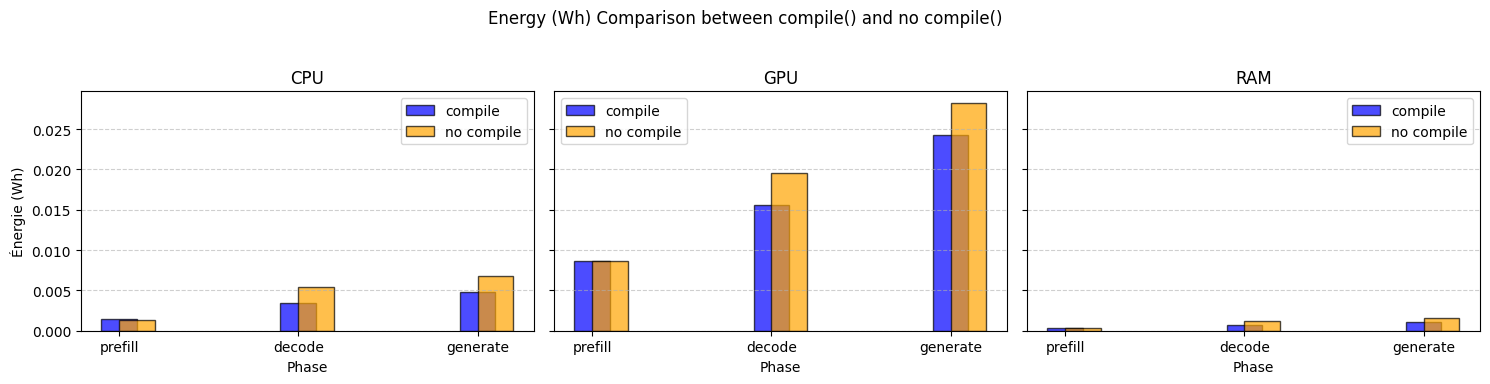

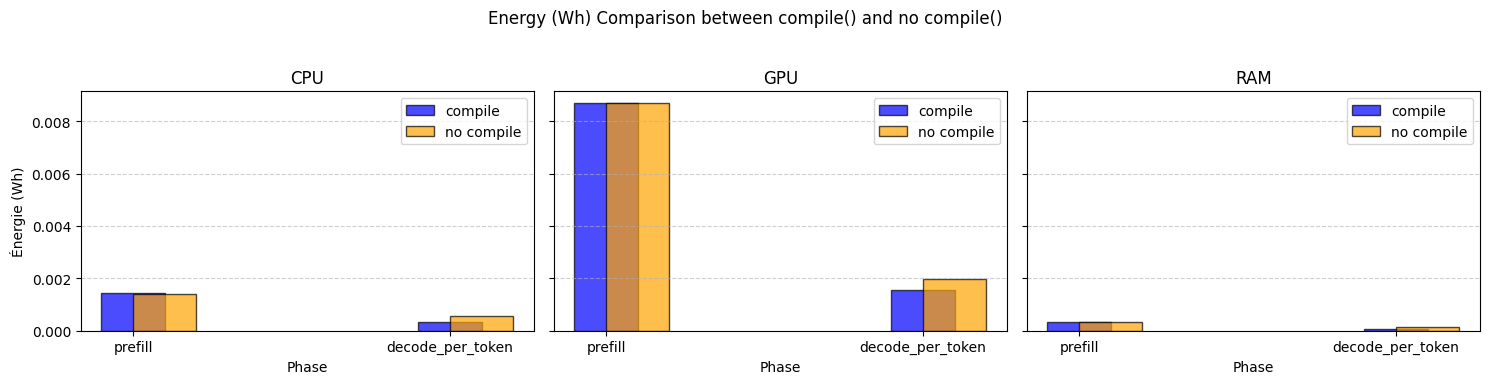

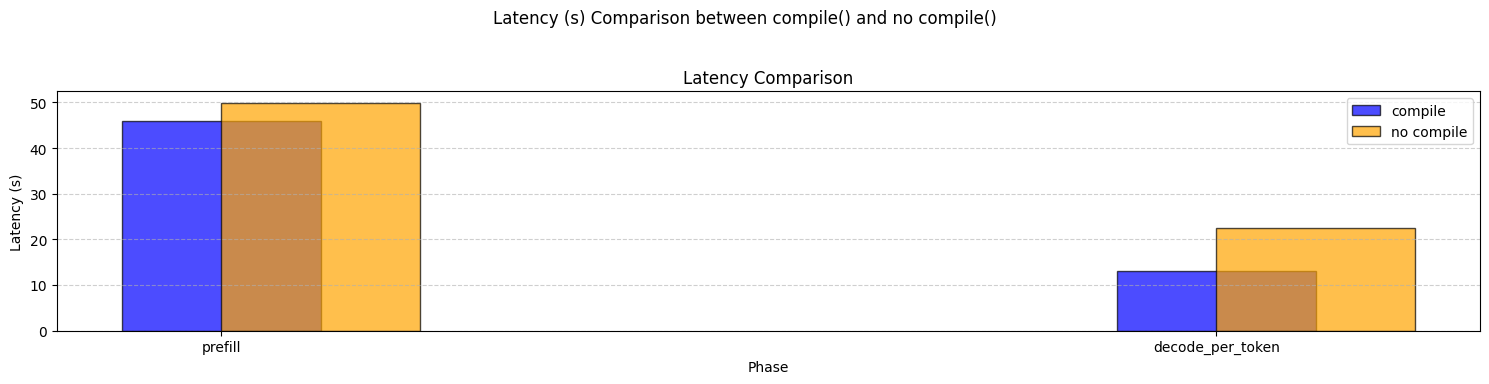

In [32]:
import pandas as pd
import matplotlib.pyplot as plt

df_compile['energy_decode_per_token_cpu'] = df_compile['energy_decode_cpu'] / df_compile['generate_length']
df_nocompile['energy_decode_per_token_cpu'] = df_nocompile['energy_decode_cpu'] / df_nocompile['generate_length']
df_compile['energy_decode_per_token_gpu'] = df_compile['energy_decode_gpu'] / df_compile['generate_length']
df_nocompile['energy_decode_per_token_gpu'] = df_nocompile['energy_decode_gpu'] / df_nocompile['generate_length']
df_compile['energy_decode_per_token_ram'] = df_compile['energy_decode_ram'] / df_compile['generate_length']
df_nocompile['energy_decode_per_token_ram'] = df_nocompile['energy_decode_ram'] / df_nocompile['generate_length']
df_compile['duration_decode_per_token'] = df_compile['duration_decode'] / df_compile['generate_length']
df_nocompile['duration_decode_per_token'] = df_nocompile['duration_decode'] / df_nocompile['generate_length']


# Initialisation
phases = ["prefill", "decode", "generate"]
devices = ["cpu", "gpu", "ram"]

# Création des subplots
fig, axs = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
fig.suptitle("Energy (Wh) Comparison between compile() and no compile()")

for idx, device in enumerate(devices):
    energies_compile = [df_compile[f"energy_{phase}_{device}"].iloc[0] * 1000 for phase in phases]
    energies_nocompile = [df_nocompile[f"energy_{phase}_{device}"].iloc[0] * 1000 for phase in phases]
    
    axs[idx].bar(phases, energies_compile, width=0.2, label="compile", align='center', color='blue', alpha=0.7, edgecolor='black')
    axs[idx].bar(phases, energies_nocompile, width=0.2, label="no compile", align='edge', color='orange', alpha=0.7, edgecolor='black')
    axs[idx].set_title(device.upper())
    axs[idx].set_xlabel("Phase")
    if idx == 0:
        axs[idx].set_ylabel("Énergie (Wh)")
    axs[idx].grid(True, axis='y', linestyle='--', alpha=0.6)
    axs[idx].legend()

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


# Initialisation
phases = ["prefill", "decode_per_token"]
devices = ["cpu", "gpu", "ram"]

# Création des subplots
fig, axs = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
fig.suptitle("Energy (Wh) Comparison between compile() and no compile()")

for idx, device in enumerate(devices):
    energies_compile = [df_compile[f"energy_{phase}_{device}"].iloc[0] * 1000 for phase in phases]
    energies_nocompile = [df_nocompile[f"energy_{phase}_{device}"].iloc[0] * 1000 for phase in phases]
    
    axs[idx].bar(phases, energies_compile, width=0.2, label="compile", align='center', color='blue', alpha=0.7, edgecolor='black')
    axs[idx].bar(phases, energies_nocompile, width=0.2, label="no compile", align='edge', color='orange', alpha=0.7, edgecolor='black')
    axs[idx].set_title(device.upper())
    axs[idx].set_xlabel("Phase")
    if idx == 0:
        axs[idx].set_ylabel("Énergie (Wh)")
    axs[idx].grid(True, axis='y', linestyle='--', alpha=0.6)
    axs[idx].legend()

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

phases = ["prefill", "decode_per_token"]

fig, axs = plt.subplots(1, 1, figsize=(15, 4), sharey=True)
fig.suptitle("Latency (s) Comparison between compile() and no compile()")

latency_compile = [df_compile[f"duration_{phase}"].iloc[0] for phase in phases]
latency_nocompile = [df_nocompile[f"duration_{phase}"].iloc[0] for phase in phases]

axs.bar(phases, latency_compile, width=0.2, label="compile", align='center', color='blue', alpha=0.7, edgecolor='black')
axs.bar(phases, latency_nocompile, width=0.2, label="no compile", align='edge', color='orange', alpha=0.7, edgecolor='black')
axs.set_title("Latency Comparison")
axs.set_xlabel("Phase")
axs.set_ylabel("Latency (s)")
axs.grid(True, axis='y', linestyle='--', alpha=0.6)
axs.legend()
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


In [33]:
df_nocompile = pd.read_csv("./tmp/energyllama8B_decodeprefillgenerate_results_bs1_input_length128_runs500_2025-07-10-16-46-55.csv")
df_nocompile['duration_decode_per_token'] = df_nocompile['duration_decode'] / (df_nocompile['generate_length']-1)
df_nocompile['energy_decode_per_token_cpu'] = df_nocompile['energy_decode_cpu'] / (df_nocompile['generate_length'] - 1)
df_nocompile['energy_decode_per_token_gpu'] = df_nocompile['energy_decode_gpu'] / (df_nocompile['generate_length'] - 1)
df_nocompile['energy_decode_per_token_ram'] = df_nocompile['energy_decode_ram'] / (df_nocompile['generate_length'] - 1)
df_nocompile

,model,batch_size,input_length,generate_length,runs,duration_prefill,energy_prefill_cpu,energy_prefill_gpu,energy_prefill_ram,duration_generate,...,energy_generate_gpu,energy_generate_ram,duration_decode,energy_decode_cpu,energy_decode_gpu,energy_decode_ram,duration_decode_per_token,energy_decode_per_token_cpu,energy_decode_per_token_gpu,energy_decode_per_token_ram
0,meta-llama/Llama-3.1-8B-Instruct,1,128,10,500,49.812402,0.000001,0.000008,2.823908e-07,277.973219,...,0.000029,0.000002,228.160816,0.000006,0.00002,0.000001,25.351202,6.627699e-07,0.000002,1.408409e-07


In [34]:
df_compile = pd.read_csv("./tmp/energyllama8Bcompile_decodeprefillgenerate_results_bs1_input_length128_runs500_2025-07-10-16-50-37.csv")
df_compile['duration_decode_per_token'] = df_compile['duration_decode'] / (df_compile['generate_length']-1)
df_compile['energy_decode_per_token_cpu'] = df_compile['energy_decode_cpu'] / (df_compile['generate_length'] - 1)
df_compile['energy_decode_per_token_gpu'] = df_compile['energy_decode_gpu'] / (df_compile['generate_length'] - 1)
df_compile['energy_decode_per_token_ram'] = df_compile['energy_decode_ram'] / (df_compile['generate_length'] - 1)

df_compile

,model,batch_size,input_length,generate_length,runs,duration_prefill,energy_prefill_cpu,energy_prefill_gpu,energy_prefill_ram,duration_generate,...,energy_generate_gpu,energy_generate_ram,duration_decode,energy_decode_cpu,energy_decode_gpu,energy_decode_ram,duration_decode_per_token,energy_decode_per_token_cpu,energy_decode_per_token_gpu,energy_decode_per_token_ram
0,meta-llama/Llama-3.1-8B-Instruct,1,128,10,500,45.850773,0.000001,0.000009,2.603735e-07,174.897422,...,0.000024,9.773721e-07,129.046648,0.000003,0.000016,7.169986e-07,14.338516,3.302183e-07,0.000002,7.966651e-08


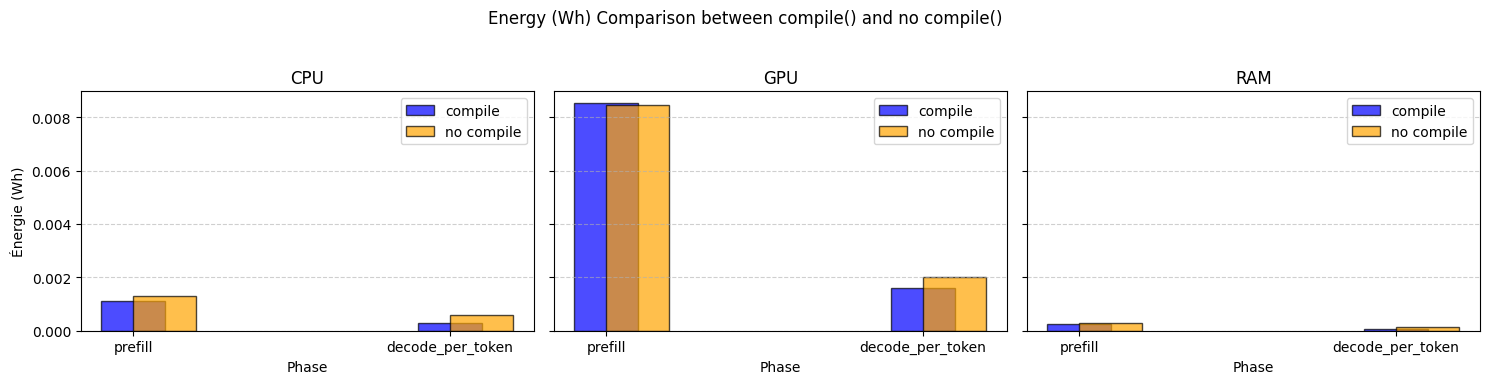

In [36]:
import pandas as pd
import matplotlib.pyplot as plt

df_compile['energy_decode_per_token_cpu'] = df_compile['energy_decode_cpu'] / df_compile['generate_length']
df_nocompile['energy_decode_per_token_cpu'] = df_nocompile['energy_decode_cpu'] / df_nocompile['generate_length']
df_compile['energy_decode_per_token_gpu'] = df_compile['energy_decode_gpu'] / df_compile['generate_length']
df_nocompile['energy_decode_per_token_gpu'] = df_nocompile['energy_decode_gpu'] / df_nocompile['generate_length']
df_compile['energy_decode_per_token_ram'] = df_compile['energy_decode_ram'] / df_compile['generate_length']
df_nocompile['energy_decode_per_token_ram'] = df_nocompile['energy_decode_ram'] / df_nocompile['generate_length']
df_compile['duration_decode_per_token'] = df_compile['duration_decode'] / df_compile['generate_length']
df_nocompile['duration_decode_per_token'] = df_nocompile['duration_decode'] / df_nocompile['generate_length']


# # Initialisation
# phases = ["prefill", "decode", "generate"]
# devices = ["cpu", "gpu", "ram"]

# # Création des subplots
# fig, axs = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
# fig.suptitle("Energy (Wh) Comparison between compile() and no compile()")

# for idx, device in enumerate(devices):
#     energies_compile = [df_compile[f"energy_{phase}_{device}"].iloc[0] * 1000 for phase in phases]
#     energies_nocompile = [df_nocompile[f"energy_{phase}_{device}"].iloc[0] * 1000 for phase in phases]
    
#     axs[idx].bar(phases, energies_compile, width=0.2, label="compile", align='center', color='blue', alpha=0.7, edgecolor='black')
#     axs[idx].bar(phases, energies_nocompile, width=0.2, label="no compile", align='edge', color='orange', alpha=0.7, edgecolor='black')
#     axs[idx].set_title(device.upper())
#     axs[idx].set_xlabel("Phase")
#     if idx == 0:
#         axs[idx].set_ylabel("Énergie (Wh)")
#     axs[idx].grid(True, axis='y', linestyle='--', alpha=0.6)
#     axs[idx].legend()

# plt.tight_layout(rect=[0, 0.03, 1, 0.95])
# plt.show()


# Initialisation
phases = ["prefill", "decode_per_token"]
devices = ["cpu", "gpu", "ram"]

# Création des subplots
fig, axs = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
fig.suptitle("Energy (Wh) Comparison between compile() and no compile()")

for idx, device in enumerate(devices):
    energies_compile = [df_compile[f"energy_{phase}_{device}"].iloc[0] * 1000 for phase in phases]
    energies_nocompile = [df_nocompile[f"energy_{phase}_{device}"].iloc[0] * 1000 for phase in phases]
    
    axs[idx].bar(phases, energies_compile, width=0.2, label="compile", align='center', color='blue', alpha=0.7, edgecolor='black')
    axs[idx].bar(phases, energies_nocompile, width=0.2, label="no compile", align='edge', color='orange', alpha=0.7, edgecolor='black')
    axs[idx].set_title(device.upper())
    axs[idx].set_xlabel("Phase")
    if idx == 0:
        axs[idx].set_ylabel("Énergie (Wh)")
    axs[idx].grid(True, axis='y', linestyle='--', alpha=0.6)
    axs[idx].legend()

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


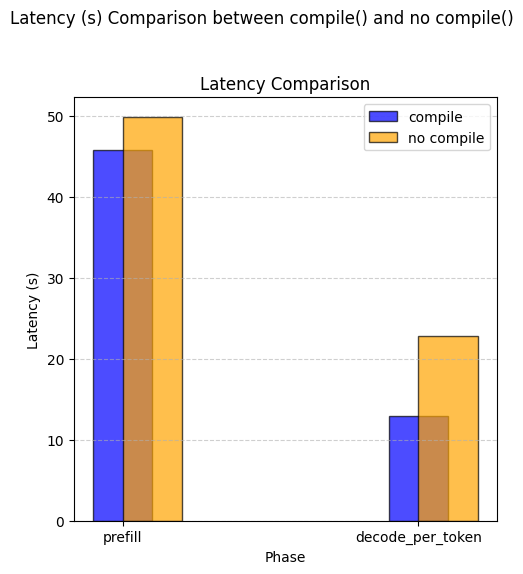

In [40]:

phases = ["prefill", "decode_per_token"]

fig, axs = plt.subplots(1, 1, figsize=(5, 6), sharey=True)
fig.suptitle("Latency (s) Comparison between compile() and no compile()")

latency_compile = [df_compile[f"duration_{phase}"].iloc[0] for phase in phases]
latency_nocompile = [df_nocompile[f"duration_{phase}"].iloc[0] for phase in phases]

axs.bar(phases, latency_compile, width=0.2, label="compile", align='center', color='blue', alpha=0.7, edgecolor='black')
axs.bar(phases, latency_nocompile, width=0.2, label="no compile", align='edge', color='orange', alpha=0.7, edgecolor='black')
axs.set_title("Latency Comparison")
axs.set_xlabel("Phase")
axs.set_ylabel("Latency (s)")
axs.grid(True, axis='y', linestyle='--', alpha=0.6)
axs.legend()
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()
